<a href="https://colab.research.google.com/github/Elnathan9414/machine_learning/blob/main/Assigment_2_Josue_Elnathan_Mbondo1_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Course: DA3B – Machine Learning
# **Assigment 2**
## Student Name : ***Josue Elnathan Mbondo***
## Instructor Name: ***Mohammed Ghori***

The **Credit Risk Dataset** contains information about borrowers, including their income, age, employment, loan amount, interest rate, loan purpose, and credit history. The target variable, **`loan_status`**, indicates whether a loan was defaulted on or not.

This project focuses on analyzing the data and using machine learning techniques to **predict loan default risk**.


## Import Librairies

In [ ]:
# Install dependencie
!pip install kagglehub

In [ ]:

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import os
import math
import numpy as np
from kagglehub import KaggleDatasetAdapter
from google.colab import drive
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler
from google.colab import files

## 1. Data Extraction

#### 1.1 Load data from kaggle

In [ ]:
path = kagglehub.dataset_download("laotse/credit-risk-dataset")

print("Dataset téléchargé dans :", path)


print(os.listdir(path))
file_path = os.path.join(path, "credit_risk_dataset.csv")

df = pd.read_csv(file_path)

Using Colab cache for faster access to the 'credit-risk-dataset' dataset.
Dataset téléchargé dans : /kaggle/input/credit-risk-dataset
['credit_risk_dataset.csv']


#### 1.2  Descover dataset

In [ ]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


#### 1.3  Data profiling

##### a. Number of rows and culumns

In [ ]:
df.shape

(32581, 12)

In [ ]:
# Get the number of rows and columns in the DataFrame
rows = len(df.axes[0])  # Get the number of rows by accessing the length of the first axis
cols = len(df.axes[1])  # Get the number of columns by accessing the length of the second axis

# Print the number of rows and columns
print("Number of Rows: " + str(rows))  # Print the number of rows
print("Number of Columns: " + str(cols))  # Print the number of columns

Number of Rows: 32581
Number of Columns: 12


##### b. Columns Review

In [ ]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


##### c. Categorize the colums based on datatype

In [ ]:
df.dtypes

,0
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


In [ ]:


# ==========================
# Manually created lists
# ==========================

continuous_columns = [
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income"
]

nominal_columns = [
    "person_home_ownership",
    "loan_intent",
    "cb_person_default_on_file"
]

discrete_columns = [
    "person_age",
    "person_emp_length",
    "cb_person_cred_hist_length"
]

ordinal_columns = [
    "loan_grade"
]

target_columns = [
    "loan_status"
]

# ==========================
# Find the lengths of the lists
# ==========================

length_continuous = len(continuous_columns)
length_nominal = len(nominal_columns)
length_discrete = len(discrete_columns)
length_ordinal = len(ordinal_columns)
length_target = len(target_columns)

# ==========================
# Create header columns
# ==========================

header_columns = [
    f"{length_continuous} Continuous Columns",
    f"{length_nominal} Nominal Columns",
    f"{length_discrete} Discrete Columns",
    f"{length_ordinal} Ordinal Columns",
    f"{length_target} Target Column"
]

# ==========================
# Combine column names
# ==========================

continuous_columns_list = "\n".join(continuous_columns)
nominal_columns_list = "\n".join(nominal_columns)
discrete_columns_list = "\n".join(discrete_columns)
ordinal_columns_list = "\n".join(ordinal_columns)
target_columns_list = "\n".join(target_columns)

# ==========================
# Create table
# ==========================

table_data = [[
    continuous_columns_list,
    nominal_columns_list,
    discrete_columns_list,
    ordinal_columns_list,
    target_columns_list
]]

# ==========================
# Display table
# ==========================

print(tabulate(table_data, headers=header_columns, tablefmt="grid"))

+------------------------+---------------------------+----------------------------+---------------------+-------------------+
| 4 Continuous Columns   | 3 Nominal Columns         | 3 Discrete Columns         | 1 Ordinal Columns   | 1 Target Column   |
+========================+===========================+============================+=====================+===================+
| person_income          | person_home_ownership     | person_age                 | loan_grade          | loan_status       |
| loan_amnt              | loan_intent               | person_emp_length          |                     |                   |
| loan_int_rate          | cb_person_default_on_file | cb_person_cred_hist_length |                     |                   |
| loan_percent_income    |                           |                            |                     |                   |
+------------------------+---------------------------+----------------------------+---------------------+-------------

### 2. Eploratory Data Analysis

#### 2.1 Basic Statistics

In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


#### 2.2 Data Distribution

##### a. Numerical Data

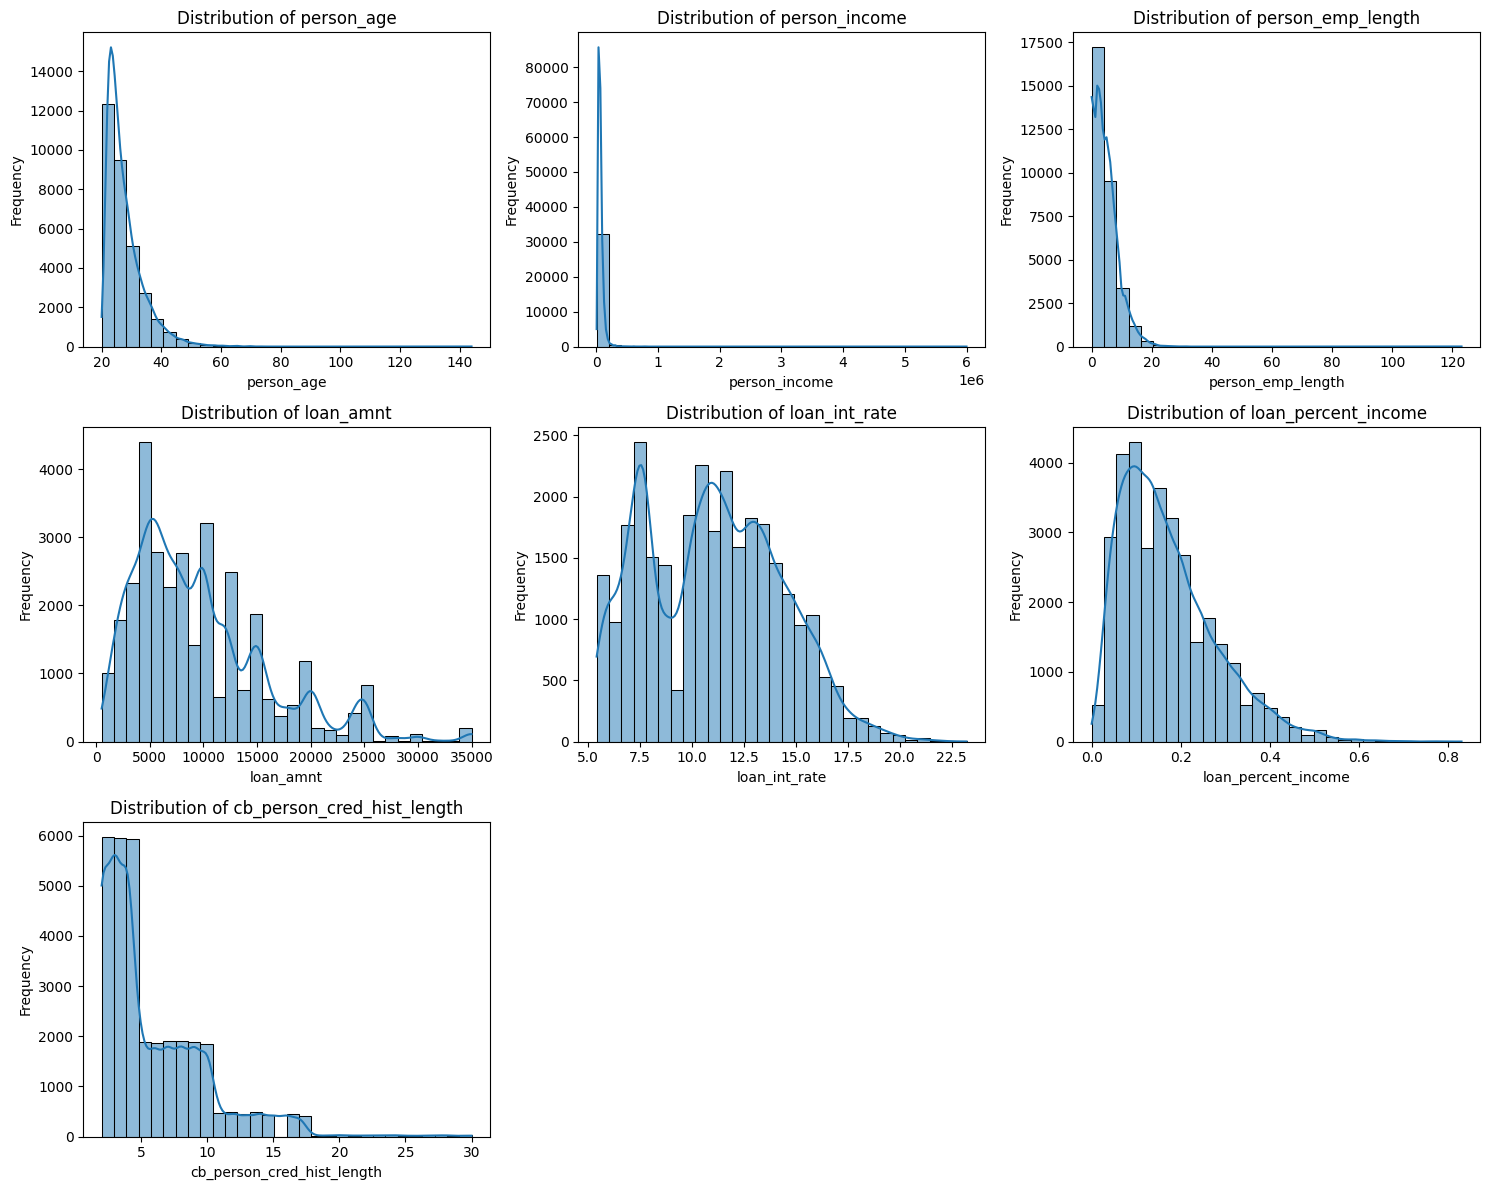

In [ ]:
numerical_columns = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_columns):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#### b. Categorical Data

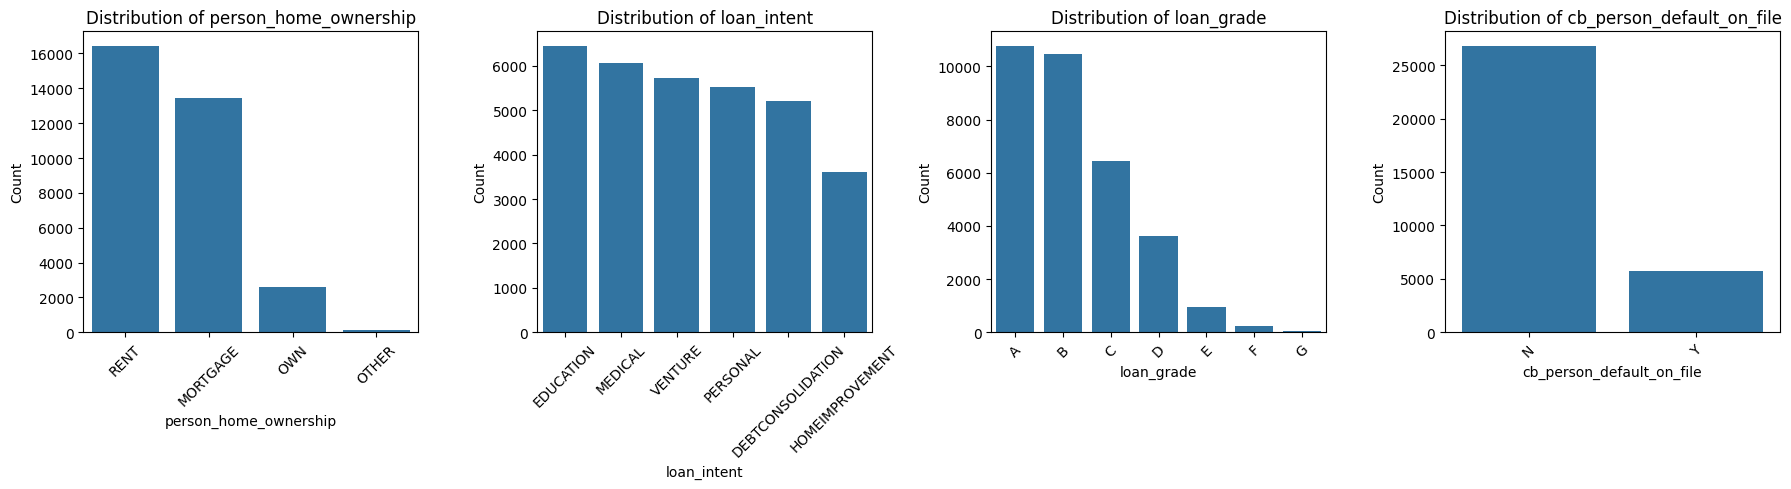

In [ ]:

# Select categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Number of rows needed
n_cols = 4
n_rows = math.ceil(len(categorical_cols) / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Plot each categorical variable
for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        ax=axes[i]
    )

    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty plots
for i in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#### c. Outliers

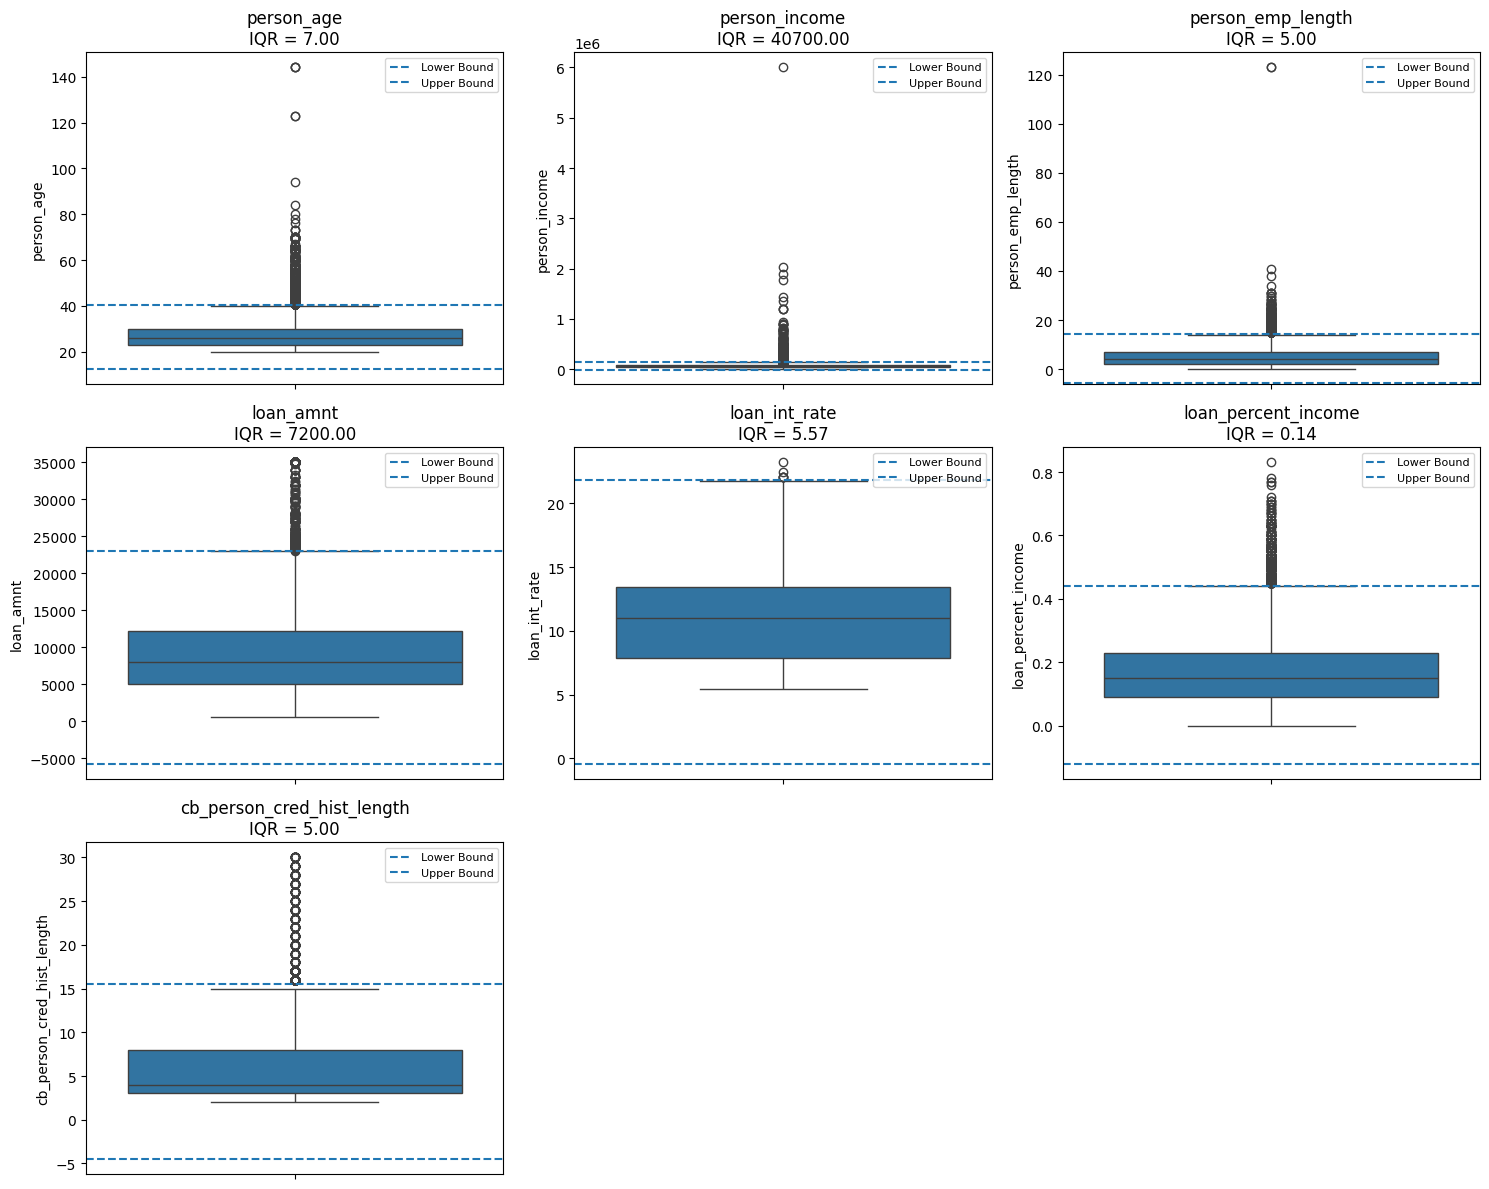

In [ ]:
plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_columns):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    plt.subplot(3, 3, i + 1)

    sns.boxplot(y=df[col])

    # IQR boundaries
    plt.axhline(lower_bound, linestyle='--', label='Lower Bound')
    plt.axhline(upper_bound, linestyle='--', label='Upper Bound')

    plt.title(f'{col}\nIQR = {IQR:.2f}')
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

The boxplots reveal the presence of outliers in all numerical variables. The most noticeable outliers are found in person_income, loan_amnt, and person_emp_length, while person_age and cb_person_cred_hist_length also contain a few extreme values. The loan_int_rate variable has fewer outliers and appears more evenly distributed. These observations suggest that outlier treatment may be considered during the data preprocessing stage.

### 2.3 Bibariate Analysis

#### a. Numerical data vs loan status

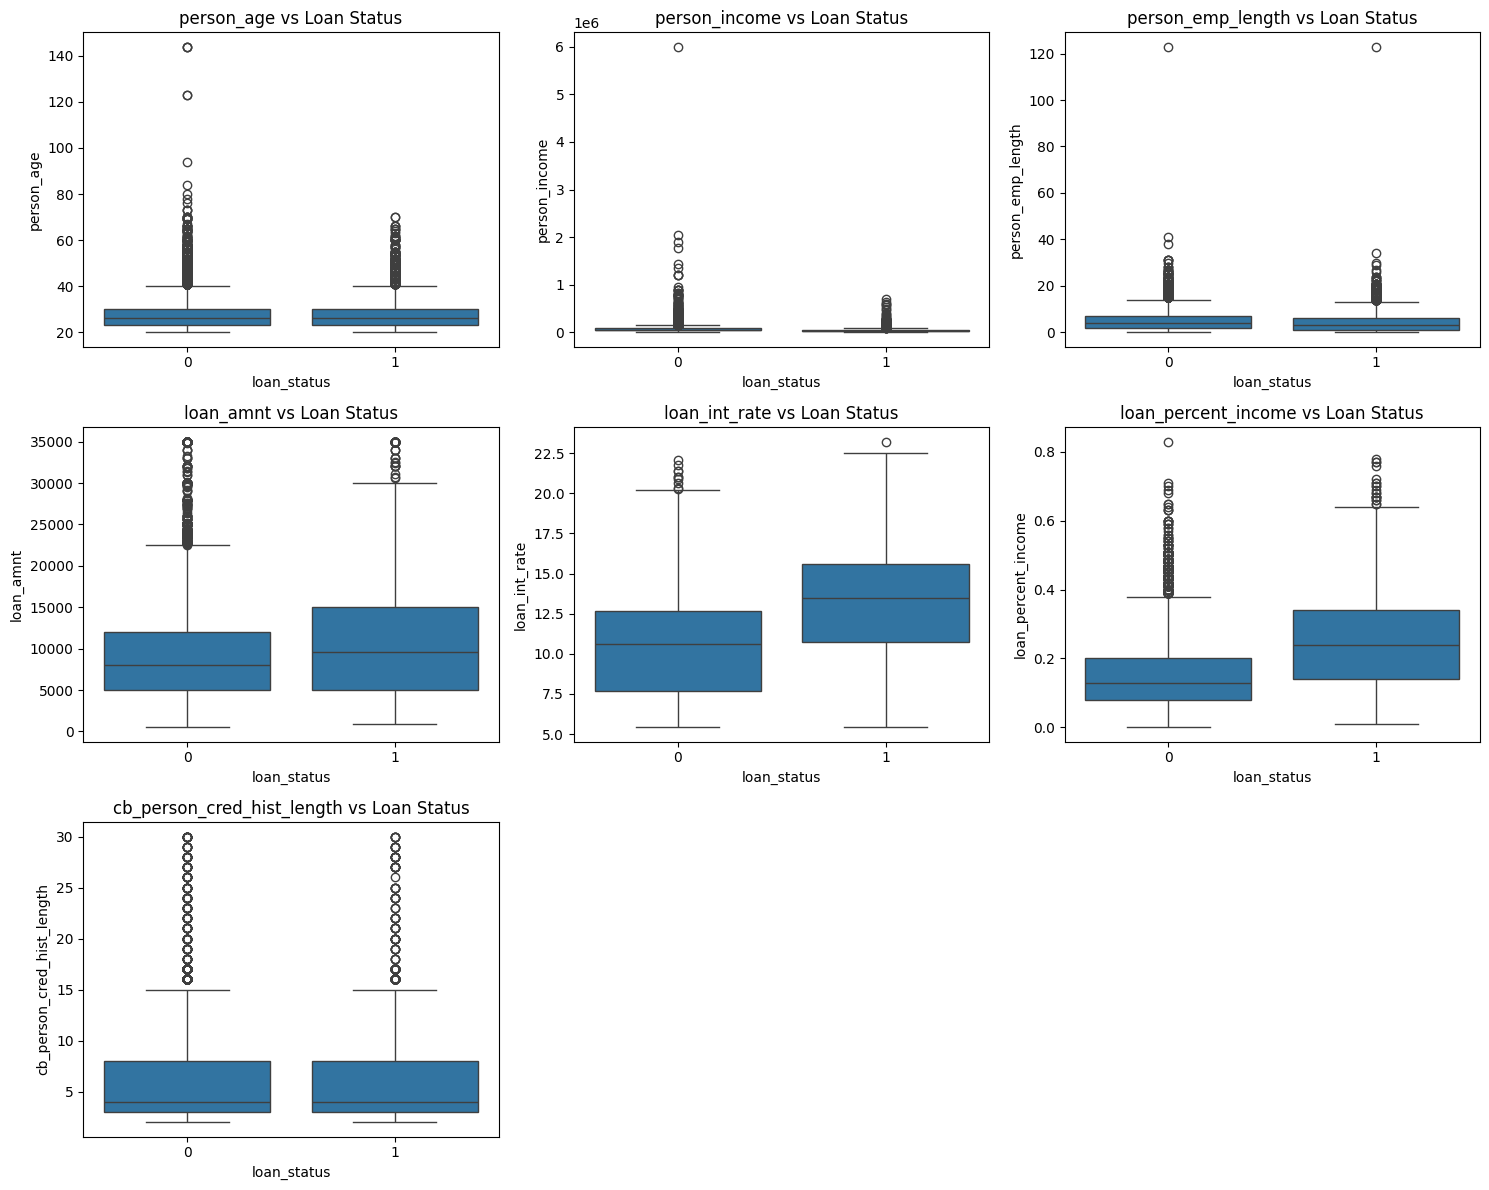

In [ ]:
numerical_columns = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

plt.figure(figsize=(15,12))

for i, col in enumerate(numerical_columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(data=df, x="loan_status", y=col)
    plt.title(f"{col} vs Loan Status")

plt.tight_layout()
plt.show()

#### b. Categorical values vs loan status

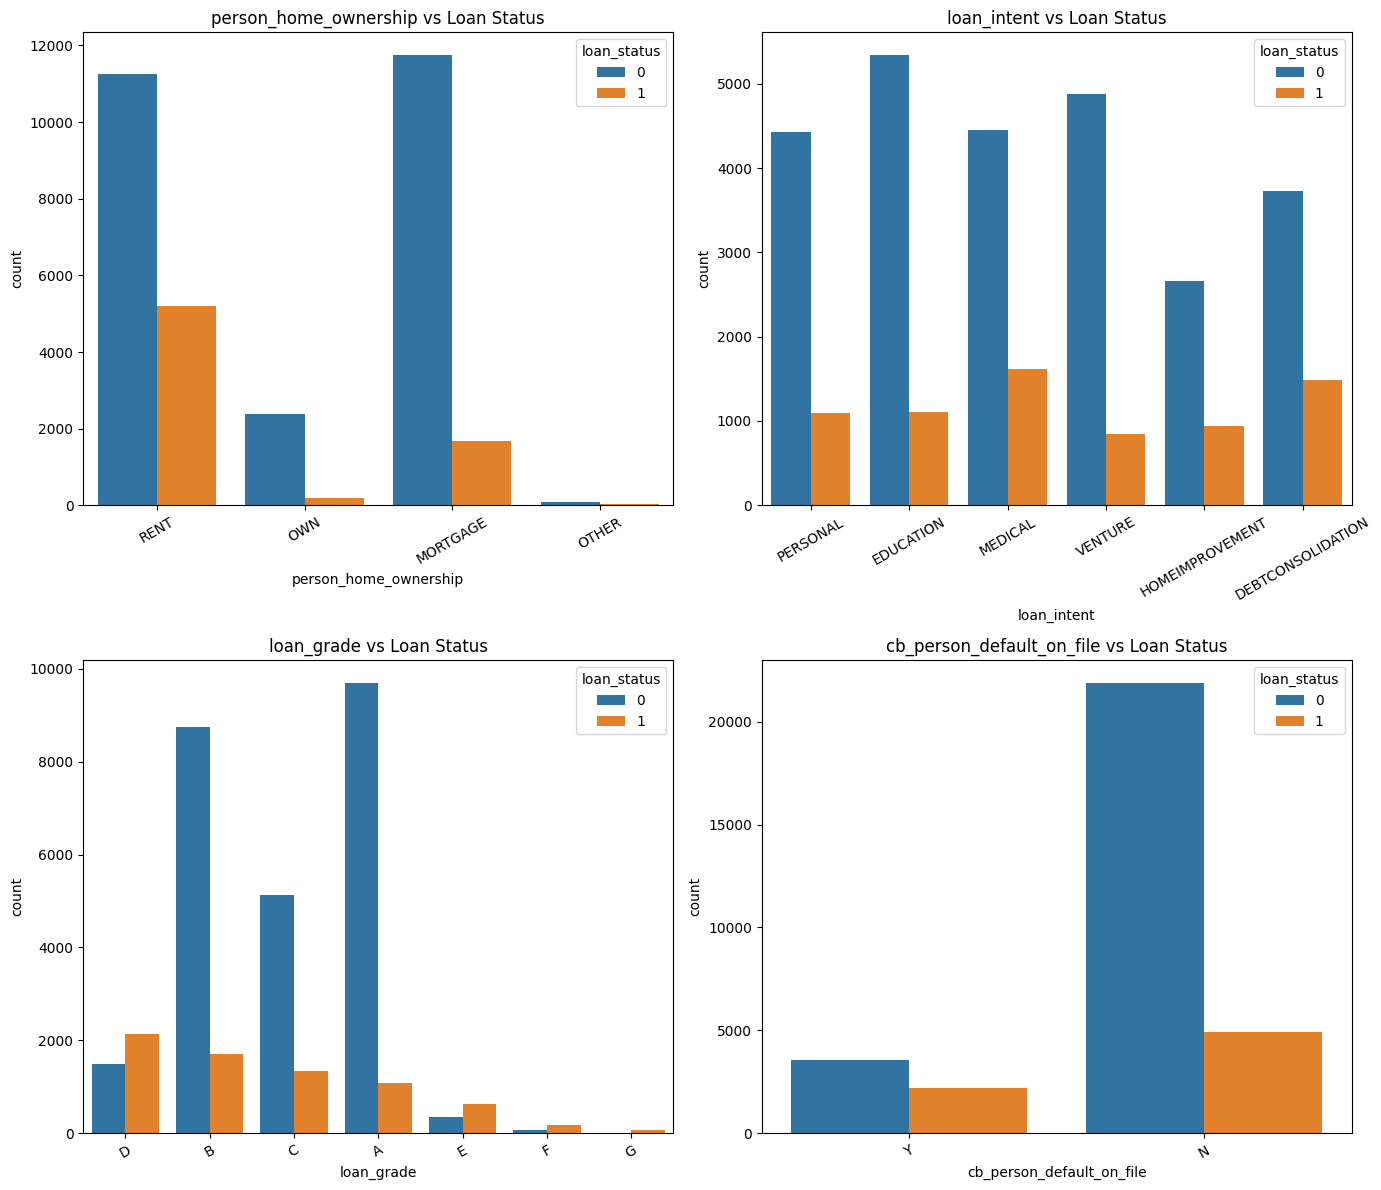

In [ ]:
categorical_columns = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

plt.figure(figsize=(14,12))

for i, col in enumerate(categorical_columns):
    plt.subplot(2,2,i+1)
    sns.countplot(data=df, x=col, hue="loan_status")
    plt.xticks(rotation=30)
    plt.title(f"{col} vs Loan Status")

plt.tight_layout()
plt.show()

#### c. Skewness

In [ ]:
skewness_df = pd.DataFrame({
    "Variable": numerical_columns,
    "Skewness": [df[col].skew() for col in numerical_columns]
})

skewness_df

,Variable,Skewness
0,person_age,2.581393
1,person_income,32.865349
2,person_emp_length,2.614455
3,loan_amnt,1.192477
4,loan_int_rate,0.208550
5,loan_percent_income,1.064669
6,cb_person_cred_hist_length,1.661790


#### d. Correlation Heatmap

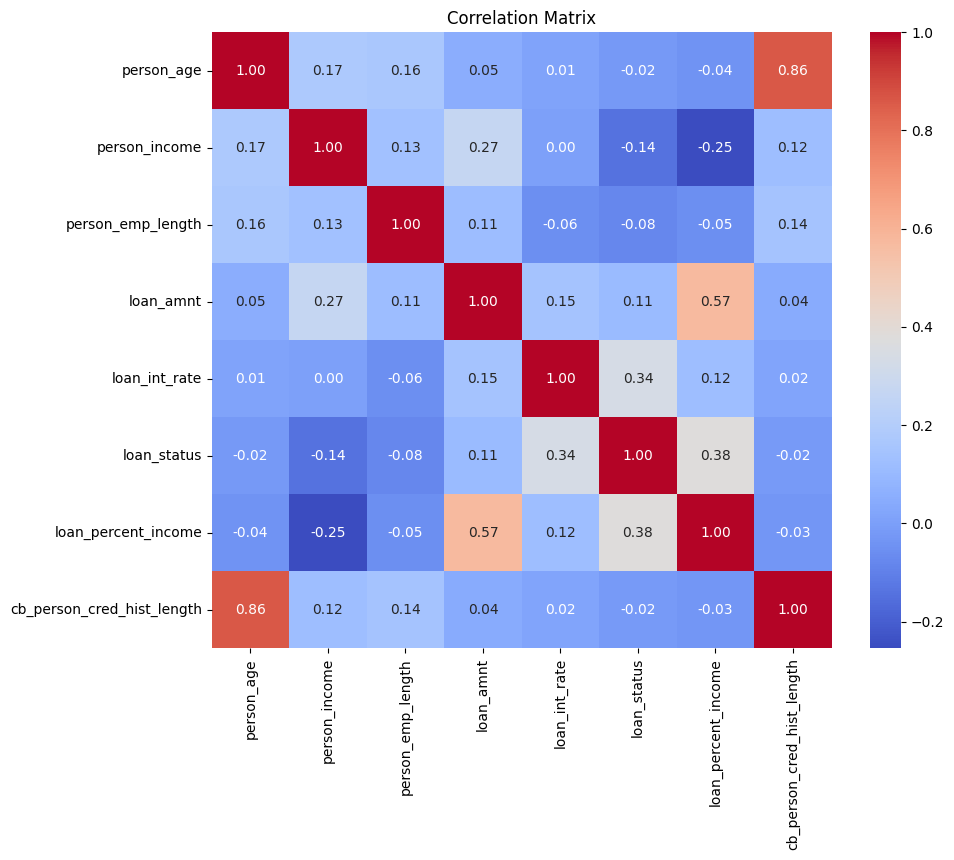

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows that most numerical variables have weak correlations, indicating low multicollinearity. The strongest positive correlation is between person_age and cb_person_cred_hist_length (0.86), which is expected since older individuals generally have a longer credit history. A moderate positive correlation exists between loan_amnt and loan_percent_income (0.57). Regarding the target variable (loan_status), the highest correlations are with loan_percent_income (0.38) and loan_int_rate (0.34), suggesting that these variables may be important predictors in the machine learning model.

#### e. pair plot

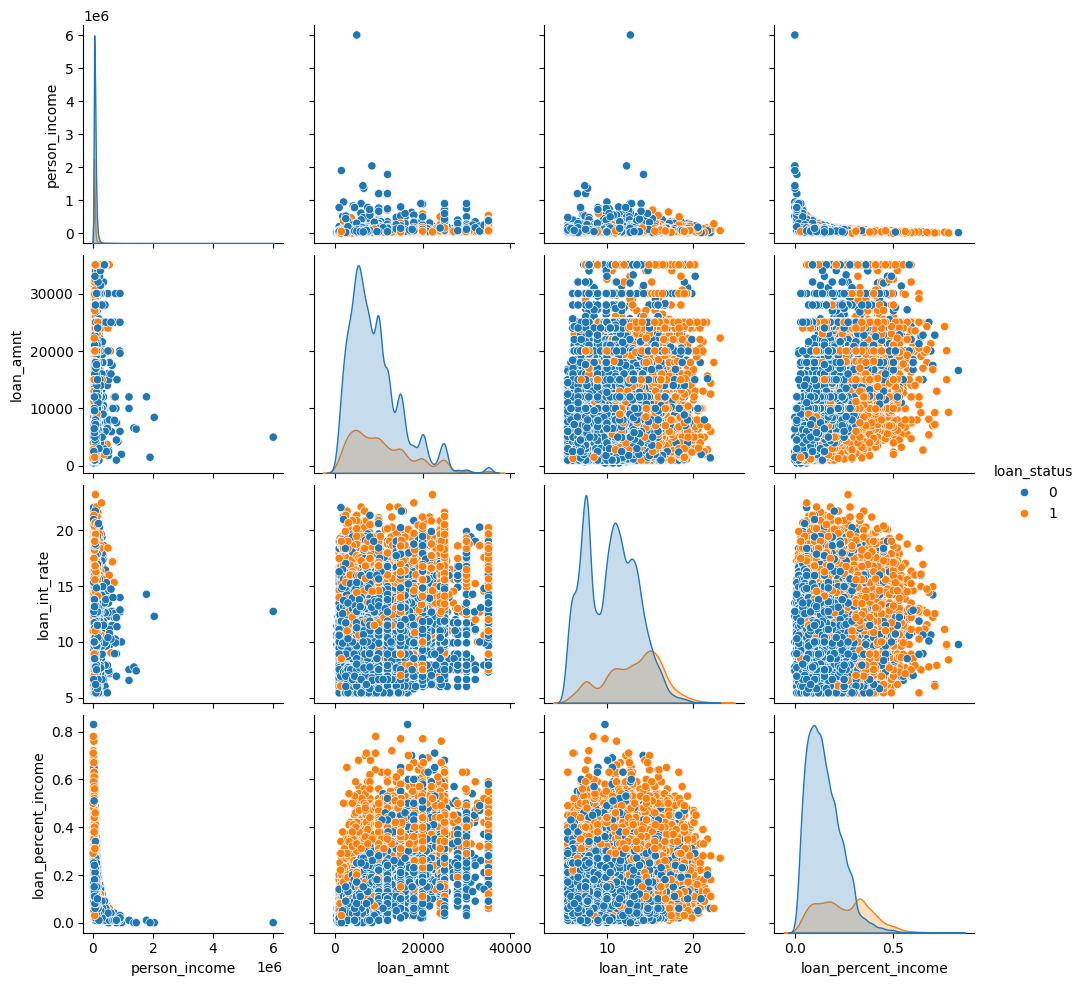

In [ ]:
selected = [
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "loan_status"
]

sns.pairplot(df[selected], hue="loan_status")
plt.show()

The pairplot shows that most variables are right-skewed and contain several outliers, especially person_income and loan_amnt. A positive relationship exists between loan_amnt and loan_percent_income, while higher incomes tend to correspond to lower loan-to-income ratios. Although the two loan status classes overlap considerably, applicants with higher interest rates and higher loan-to-income ratios are more frequently associated with loan_status = 1, suggesting that these variables may be important predictors for the machine learning model.

### 3. Data Quality

#### 3.1 Data cleaning

#### a. Missing Data

In [ ]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [ ]:
# Missing percent
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.747000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.563856
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64


#### b. Handle missing values using median imputation

In [ ]:
df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median()
)

df["loan_int_rate"] = df["loan_int_rate"].fillna(
    df["loan_int_rate"].median()
)

# Verify missing values
df[["person_emp_length", "loan_int_rate"]].isnull().sum()

,0
person_emp_length,0
loan_int_rate,0


Median imputation was used to handle the missing values in
person_emp_length and loan_int_rate. This method was chosen
because both variables are highly right-skewed, with skewness
values of 2.747 and 9.564 respectively. The median is less
sensitive to extreme values and outliers than the mean, making
it more appropriate for these variables.

####  c. Cleanse Outliers with Winsorization

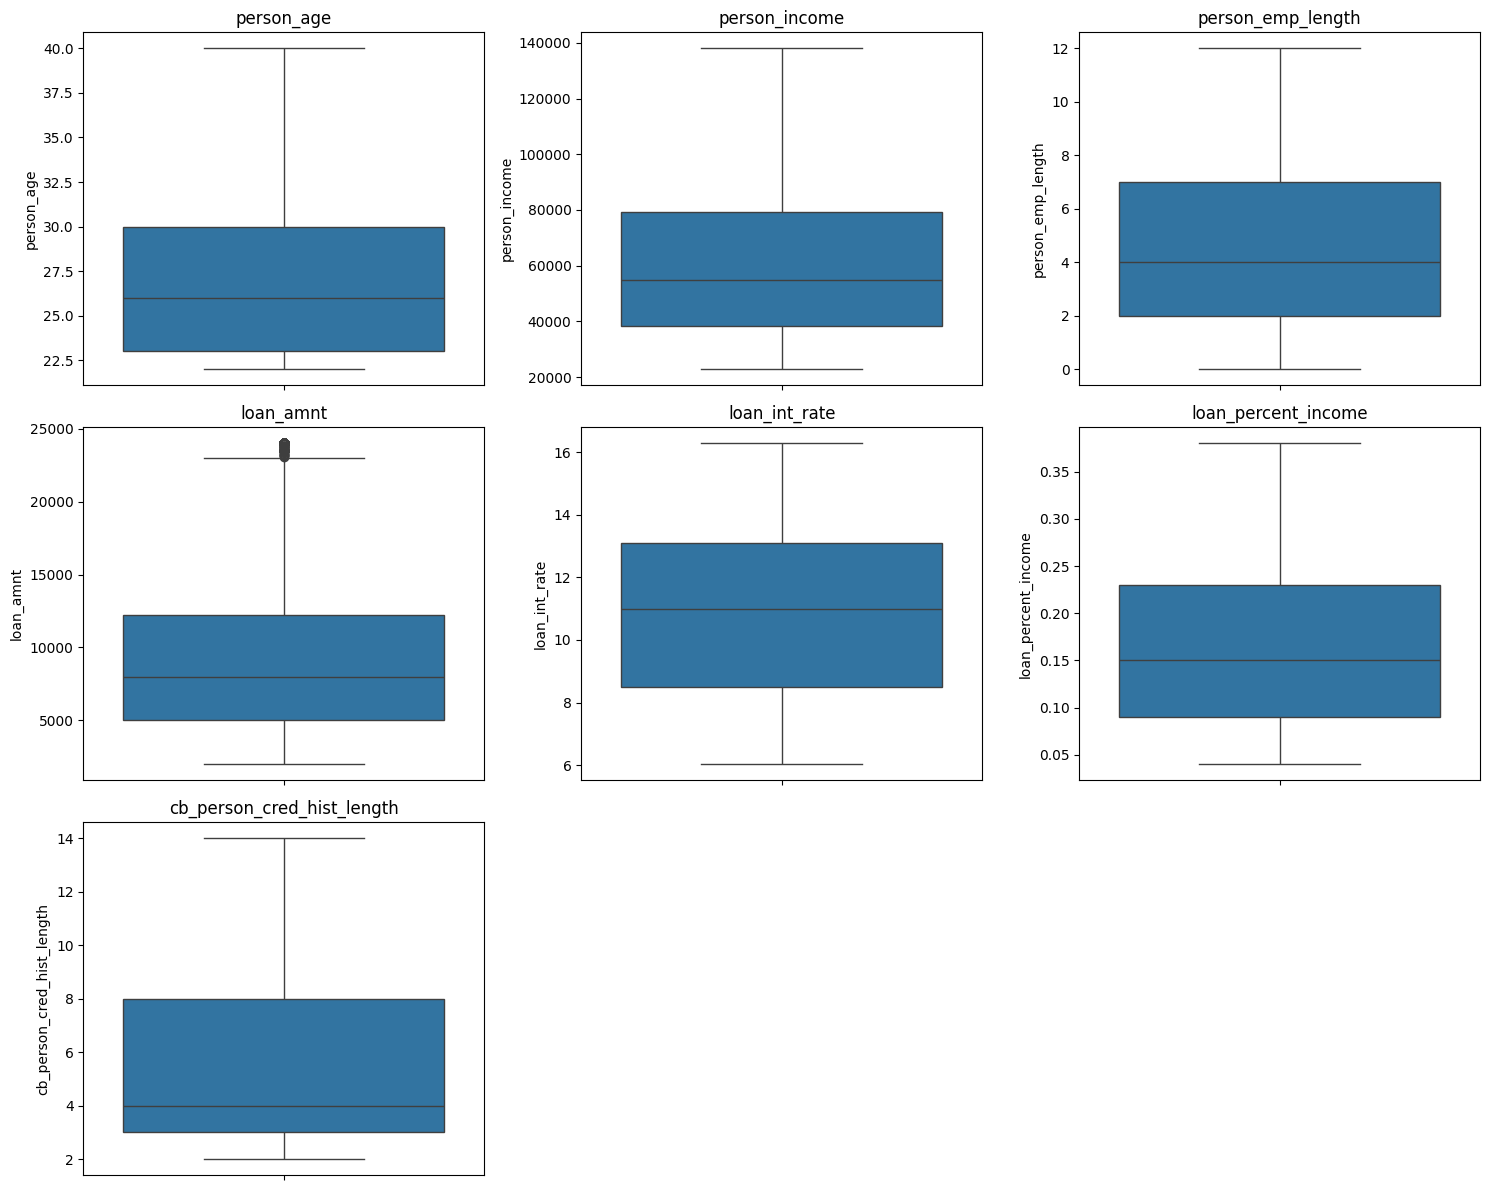

In [ ]:
numerical_columns = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

for col in numerical_columns:
    mask = df[col].notna()  # Conserver les NaN
    df.loc[mask, col] = winsorize(df.loc[mask, col], limits=[0.05, 0.05])

plt.figure(figsize=(15,12))

for i, col in enumerate(numerical_columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### d. Duplicate data

In [ ]:
# Check for duplicate rows
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 196


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (32385, 12)


Duplicate records were identified and examined by comparing the complete rows. Exact duplicate records were removed to avoid giving repeated observations additional weight during analysis and modeling."

### 4. Feature optimization

#### a. Feature Engineering

In [ ]:
# Create a new feature: high loan burden

df["high_loan_burden"] = (
    df["loan_percent_income"] > 0.20
).astype(int)

df[["loan_percent_income", "high_loan_burden"]].head()

,loan_percent_income,high_loan_burden
0,0.38,1
1,0.10,0
2,0.38,1
3,0.38,1
4,0.38,1


#### b. Log transformation

In [ ]:
# Log transformation of income

df["person_income_log"] = np.log1p(df["person_income"])

df[["person_income", "person_income_log"]].head()

,person_income,person_income_log
0,59000,10.985310
1,22880,10.038062
2,22880,10.038062
3,65500,11.089821
4,54400,10.904138


In [ ]:
print("Original skewness:",
      df["person_income"].skew())

print("Transformed skewness:",
      df["person_income_log"].skew())

Original skewness: 0.8991341306149243
Transformed skewness: 0.027898499714011333


#### c.  Encoding categorical data (One-Hot Encoding)

In [ ]:
categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]
# One-Hot Encoding

df_encoded = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True
)

df_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,high_loan_burden,person_income_log,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,12.0,24000,16.02,1,0.38,3,1,10.985310,...,False,True,False,False,False,True,False,False,False,True
1,22,22880,5.0,2000,11.14,0,0.10,2,0,10.038062,...,False,False,False,True,False,False,False,False,False,False
2,25,22880,1.0,5500,12.87,1,0.38,3,1,10.038062,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,24000,15.23,1,0.38,2,1,11.089821,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,24000,14.27,1,0.38,4,1,10.904138,...,True,False,False,False,True,False,False,False,False,True


### 5. Feature Set Finalization

#### a. Define the target

In [ ]:
# Define target variable

target = "loan_status"

y = df[target]

print("Target variable:", target)
print("Target values:")
print(y.value_counts())

Target variable: loan_status
Target values:
loan_status
0    25301
1     7084
Name: count, dtype: int64


#### b. Define the features

In [ ]:
# Define final features

features = [
    "person_age",
    "person_income",
    "person_home_ownership",
    "person_emp_length",
    "loan_intent",
    "loan_grade",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_default_on_file",
    "cb_person_cred_hist_length"
]

X = df[features]

print("Number of features:", len(features))
print("Features:")
print(features)

Number of features: 11
Features:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


#### c. Check the final dattaset

In [ ]:
# Check the final feature set

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature matrix shape: (32385, 11)
Target shape: (32385,)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,12.0,PERSONAL,D,24000,16.02,0.38,Y,3
1,22,22880,OWN,5.0,EDUCATION,B,2000,11.14,0.10,N,2
2,25,22880,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.38,N,3
3,23,65500,RENT,4.0,MEDICAL,C,24000,15.23,0.38,N,2
4,24,54400,RENT,8.0,MEDICAL,C,24000,14.27,0.38,Y,4


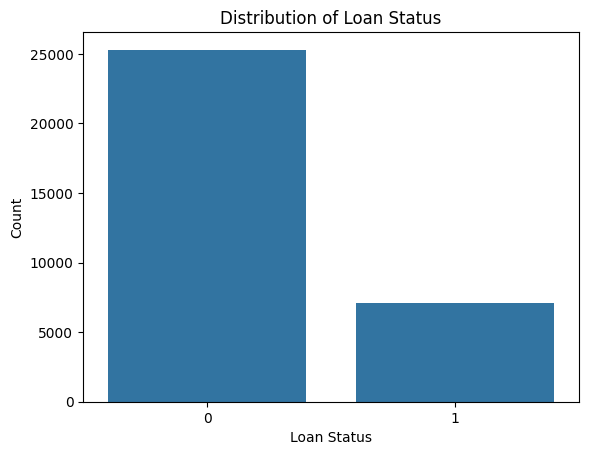

In [ ]:
sns.countplot(x=y)

plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

#### d. Save final datasset

In [ ]:
# Save the final dataset
df_encoded.to_csv("credit_risk_final.csv", index=False)

# Download the file

files.download("credit_risk_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

`loan_status` was selected as the target variable, while the remaining relevant demographic, financial, loan, and credit history variables were retained as features. Missing values and duplicate records were checked to ensure the final feature set was suitable for modeling.


### Summary

In this project, the Credit Risk Dataset was cleaned and prepared for machine learning. Missing values were handled using median imputation, duplicate records were checked, and outliers and skewness were analyzed. Feature optimization included feature engineering, transformation, categorical encoding, and standardization. Finally, the target variable `loan_status` and the relevant features were selected for the next stage of predictive modeling.
